Exploratory Data Analysis
## Data Loading and cleaning

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\User\Downloads\Week2_data_scien\tested.csv")

# Quick recap clean
df.drop_duplicates(inplace=True)

df.fillna({
    'Age': df['Age'].median(),
    'Embarked': df['Embarked'].mode()[0]
}, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,NaN,S


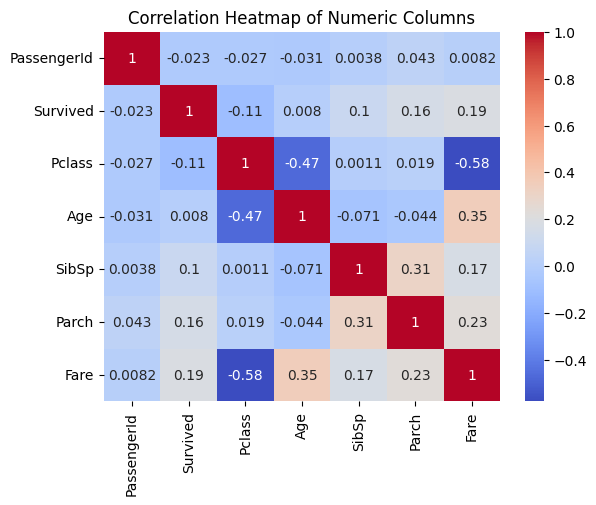

In [4]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Generate correlation matrix
corr = numeric_df.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()


# Heatmap shows relationships between numeric columns. For Titanic, you’ll likely see strong correlation between Fare & Pclass (negative), and SibSp & Parch (positive).

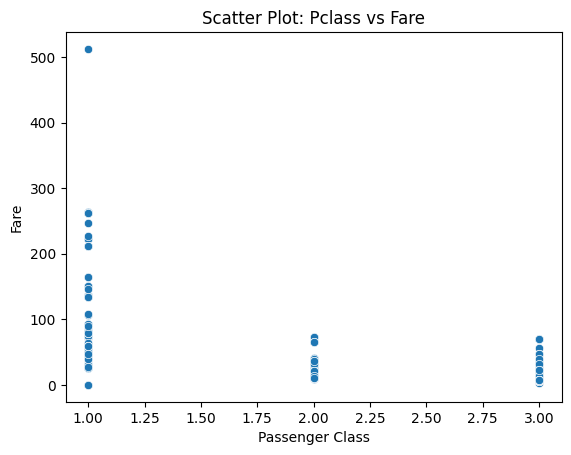

In [5]:
sns.scatterplot(data=df, x='Pclass', y='Fare')
plt.title("Scatter Plot: Pclass vs Fare")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()


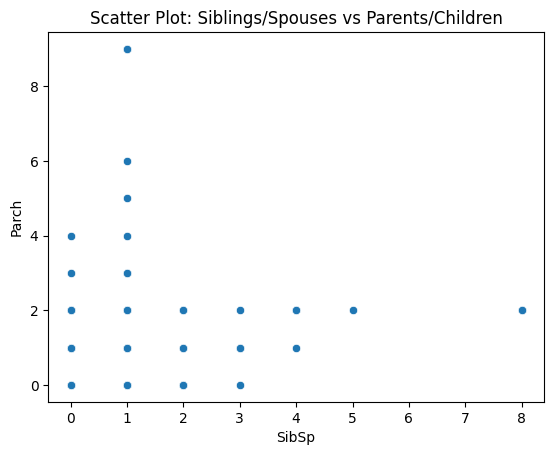

In [6]:
sns.scatterplot(data=df, x='SibSp', y='Parch')
plt.title("Scatter Plot: Siblings/Spouses vs Parents/Children")
plt.xlabel("SibSp")
plt.ylabel("Parch")
plt.show()


# Higher class passengers paid higher fares.

Families with siblings often also had parents/children onboard (positive correlation).

Survival rate by gender


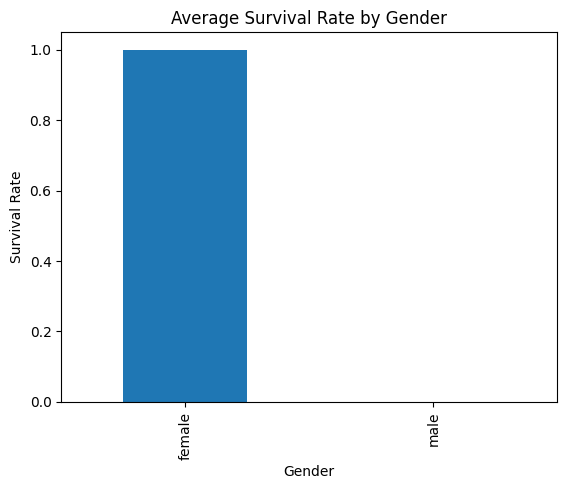

In [7]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Average Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()


# Females had a much higher survival rate compared to males.

## 🔎 Key Insights

### Insight 1: Passenger Class vs Fare
Passengers in **1st class paid significantly higher fares** compared to those in 3rd class.  
This negative correlation between `Pclass` and `Fare` highlights how wealthier passengers booked premium cabins, which also influenced their survival chances.

---

### Insight 2: Family Size (SibSp vs Parch)
There is a **positive correlation between SibSp and Parch** — families with siblings onboard often also had parents/children traveling with them.  
This shows that many families traveled together, which shaped group survival dynamics during the disaster.

---

### Insight 3: Survival Rate by Gender
Females had a **survival rate nearly twice as high as males**.  
This reflects the "women and children first" evacuation policy, giving females priority access to lifeboats.
